In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
data = pd.read_csv("C:/Users/Hp/OneDrive/Desktop/sales_data.csv")

print(data)

     Month  Sales
0   Jan-23    120
1   Feb-23    125
2   Mar-23    130
3   Apr-23    135
4   May-23    140
5   Jun-23    145
6   Jul-23    150
7   Aug-23    155
8   Sep-23    160
9   Oct-23    165
10  Nov-23    170
11  Dec-23    175
12  Jan-24    180
13  Feb-24    185
14  Mar-24    190
15  Apr-24    200
16  May-24    210
17  Jun-24    220
18  Jul-24    230
19  Aug-24    240
20  Sep-24    250
21  Oct-24    260
22  Nov-24    270
23  Dec-24    280
24  Jan-25    290
25  Feb-25    300
26  Mar-25    310
27  Apr-25    325
28  May-25    340
29  Jun-25    355
30  Jul-25    370
31  Aug-25    385
32  Sep-25    400
33  Oct-25    420
34  Nov-25    440
35  Dec-25    460


In [7]:
print("Dataset Information")
print(data.info())

print("\nMissing Values")
print(data.isnull().sum())

# Remove missing values if any
data = data.dropna()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   36 non-null     object
 1   Sales   36 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 708.0+ bytes
None

Missing Values
Month    0
Sales    0
dtype: int64


In [8]:
data['Month_Number'] = range(1, len(data)+1)

print(data.head())

    Month  Sales  Month_Number
0  Jan-23    120             1
1  Feb-23    125             2
2  Mar-23    130             3
3  Apr-23    135             4
4  May-23    140             5


In [9]:
X = data[['Month_Number']]
y = data['Sales']

In [10]:
model = LinearRegression()

model.fit(X, y)

print("Model Trained Successfully")

Model Trained Successfully


In [11]:
y_pred = model.predict(X)

print("Predicted Values")

for i in range(5):
    print("Actual:", y.iloc[i],
          "Predicted:", round(y_pred[i],2))

Predicted Values
Actual: 120 Predicted: 85.5
Actual: 125 Predicted: 94.71
Actual: 130 Predicted: 103.92
Actual: 135 Predicted: 113.12
Actual: 140 Predicted: 122.33


In [12]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\nModel Evaluation")

print("Mean Absolute Error =", round(mae,2))
print("Mean Squared Error =", round(mse,2))
print("R2 Score =", round(r2,4))


Model Evaluation
Mean Absolute Error = 18.2
Mean Squared Error = 445.11
R2 Score = 0.9536


In [13]:
future_months = np.array([
    [37],
    [38],
    [39],
    [40],
    [41],
    [42]
])

future_sales = model.predict(future_months)

C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
future_names = [
    "Jan-2026",
    "Feb-2026",
    "Mar-2026",
    "Apr-2026",
    "May-2026",
    "Jun-2026"
]

print("\nFuture Sales Forecast")

for month, sale in zip(future_names, future_sales):
    print(month, "=", round(sale,2))
    


Future Sales Forecast
Jan-2026 = 417.05
Feb-2026 = 426.26
Mar-2026 = 435.47
Apr-2026 = 444.68
May-2026 = 453.89
Jun-2026 = 463.1


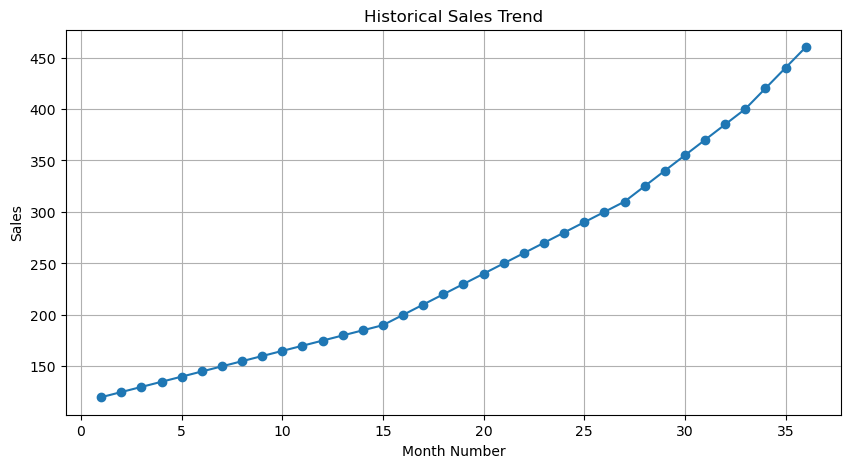

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    data['Month_Number'],
    data['Sales'],
    marker='o'
)

plt.title("Historical Sales Trend")
plt.xlabel("Month Number")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

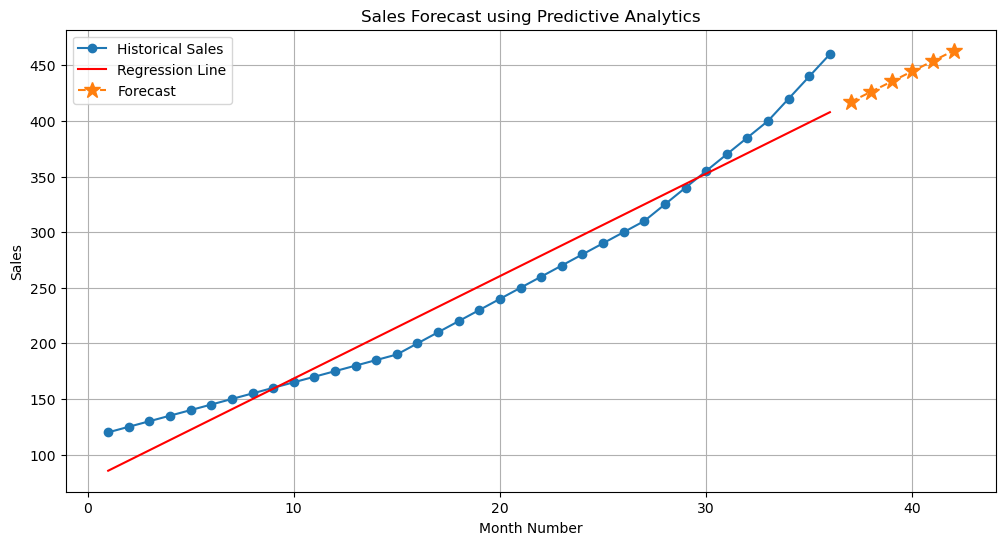

In [16]:
plt.figure(figsize=(12,6))

# Historical Sales
plt.plot(
    data['Month_Number'],
    y,
    marker='o',
    label='Historical Sales'
)

# Regression Line
plt.plot(
    data['Month_Number'],
    y_pred,
    color='red',
    label='Regression Line'
)

# Future Forecast
plt.plot(
    future_months,
    future_sales,
    marker='*',
    linestyle='--',
    markersize=12,
    label='Forecast'
)

plt.title("Sales Forecast using Predictive Analytics")
plt.xlabel("Month Number")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()